# Project data exploration - looking at relplot and scatter
Using a dataset that your group is consider using for the term project, let's do some data exploring of the different features in your dataset and their relationships

Group name:  Group 16

Created by Hrishikesh Giri (017867668), Srihan Cheemangunta (017055766), Yeqing Xu (017746079)

Last updated: 3/22/2026  

Briefly describe your dataset:
The dataset used in this notebook is the Fantasy Premier League (FPL) Player
  Performance data, sourced from the Vaastav Fantasy-Premier-League repository
  (https://github.com/vaastav/Fantasy-Premier-League).

- Timeframe: It combines gameweek-level data from the 2024-25 and 2025-26
     English Premier League seasons.
- Granularity: Each row represents a specific player's performance in a
     single Gameweek (GW).

Import your data. If you want to mount your Google drive you can use `from google.colab import drive` and `drive.mount('/content/drive')`

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the list of seasons we want to collect
seasons = ["2024-25", "2025-26"]

all_dfs = []

# 2. Loop through each season and read the data
for season in seasons:
    # Construct the URL dynamically
    url = f"https://raw.githubusercontent.com/vaastav/Fantasy-Premier-League/master/data/{season}/gws/merged_gw.csv"

    try:
        # Some older files might need 'latin-1' encoding
        temp_df = pd.read_csv(url, encoding='utf-8')
    except UnicodeDecodeError:
        temp_df = pd.read_csv(url, encoding='latin-1')
    except Exception as e:
        print(f"Could not download data for {season}: {e}")
        continue

    # 3. Add a season column so you can distinguish the data later
    temp_df['season'] = season

    # Append to our list
    all_dfs.append(temp_df)
    print(f"Successfully loaded {season}")

# 4. Combine all DataFrames into one
df_combined = pd.concat(all_dfs, ignore_index=True)

# View the result
print(f"\nFinal combined shape: {df_combined.shape}")
print(df_combined['season'].value_counts())

Successfully loaded 2024-25
Successfully loaded 2025-26

Final combined shape: (49958, 54)
season
2024-25    27605
2025-26    22353
Name: count, dtype: int64


In [ ]:
columns_to_drop = [
    'mng_clean_sheets',
    'mng_draw',
    'mng_goals_scored',
    'mng_loss',
    'mng_underdog_draw',
    'mng_underdog_win',
    'mng_win'
]

df_combined.drop(columns=columns_to_drop, inplace=True)

print(f"Columns dropped. New shape of df_combined: {df_combined.shape}")
print("Remaining columns:")
print(df_combined.columns.tolist())

Columns dropped. New shape of df_combined: (49958, 47)
Remaining columns:
['name', 'position', 'team', 'xP', 'assists', 'bonus', 'bps', 'clean_sheets', 'creativity', 'element', 'expected_assists', 'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded', 'fixture', 'goals_conceded', 'goals_scored', 'ict_index', 'influence', 'kickoff_time', 'minutes', 'modified', 'opponent_team', 'own_goals', 'penalties_missed', 'penalties_saved', 'red_cards', 'round', 'saves', 'selected', 'starts', 'team_a_score', 'team_h_score', 'threat', 'total_points', 'transfers_balance', 'transfers_in', 'transfers_out', 'value', 'was_home', 'yellow_cards', 'GW', 'season', 'clearances_blocks_interceptions', 'defensive_contribution', 'recoveries', 'tackles']


In [ ]:
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49958 entries, 0 to 49957
Data columns (total 47 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   name                             49958 non-null  object 
 1   position                         49958 non-null  object 
 2   team                             49958 non-null  object 
 3   xP                               49958 non-null  float64
 4   assists                          49958 non-null  int64  
 5   bonus                            49958 non-null  int64  
 6   bps                              49958 non-null  int64  
 7   clean_sheets                     49958 non-null  int64  
 8   creativity                       49958 non-null  float64
 9   element                          49958 non-null  int64  
 10  expected_assists                 49958 non-null  float64
 11  expected_goal_involvements       49958 non-null  float64
 12  expected_goals    

In [ ]:
df_combined.head()

,name,position,team,xP,assists,bonus,bps,clean_sheets,creativity,element,...,transfers_out,value,was_home,yellow_cards,GW,season,clearances_blocks_interceptions,defensive_contribution,recoveries,tackles
0,Alex Scott,MID,Bournemouth,1.6,0,0,11,0,12.8,77,...,0,50,False,0,1,2024-25,NaN,NaN,NaN,NaN
1,Carlos Miguel dos Santos Pereira,GK,Nott'm Forest,2.2,0,0,0,0,0.0,427,...,0,45,True,0,1,2024-25,NaN,NaN,NaN,NaN
2,Tomiyasu Takehiro,DEF,Arsenal,0.0,0,0,0,0,0.0,22,...,0,50,True,0,1,2024-25,NaN,NaN,NaN,NaN
3,Malcolm Ebiowei,MID,Crystal Palace,0.0,0,0,0,0,0.0,197,...,0,45,False,0,1,2024-25,NaN,NaN,NaN,NaN
4,Ben Brereton Díaz,MID,Southampton,1.0,0,0,-2,0,14.0,584,...,0,55,False,1,1,2024-25,NaN,NaN,NaN,NaN


### Q1: Show the number of missing data in each column of the dataframe

In [ ]:
# Set the display option to show all rows
with pd.option_context('display.max_rows', 80):
    display(df_combined.isnull().sum())

,0
name,0
position,0
team,0
xP,0
assists,0
bonus,0
bps,0
clean_sheets,0
creativity,0
element,0


### Explanation of Missing Values

The columns `clearances_blocks_interceptions`, `defensive_contribution`, `recoveries`, and `tackles` show `27605` missing values because these metrics started being recorded in the 2025-26 dataset. The 2024-25 dataset does not contain these specific features, hence the `NaN` values for that season.

### Q2: Show the data type for each column of the dataframe

In [ ]:
with pd.option_context('display.max_rows', 80):
    display(df_combined.dtypes)

,0
name,object
position,object
team,object
xP,float64
assists,int64
bonus,int64
bps,int64
clean_sheets,int64
creativity,float64
element,int64


### Q3: Create a pair plot to show pairwise relationship in this dataset.
Draw the pairwise polynomial regression lines in a different color than the data points. Use a light color for the data points to deemphasizing the points to make the regression line stand out. Include a meaningful title to the plot.

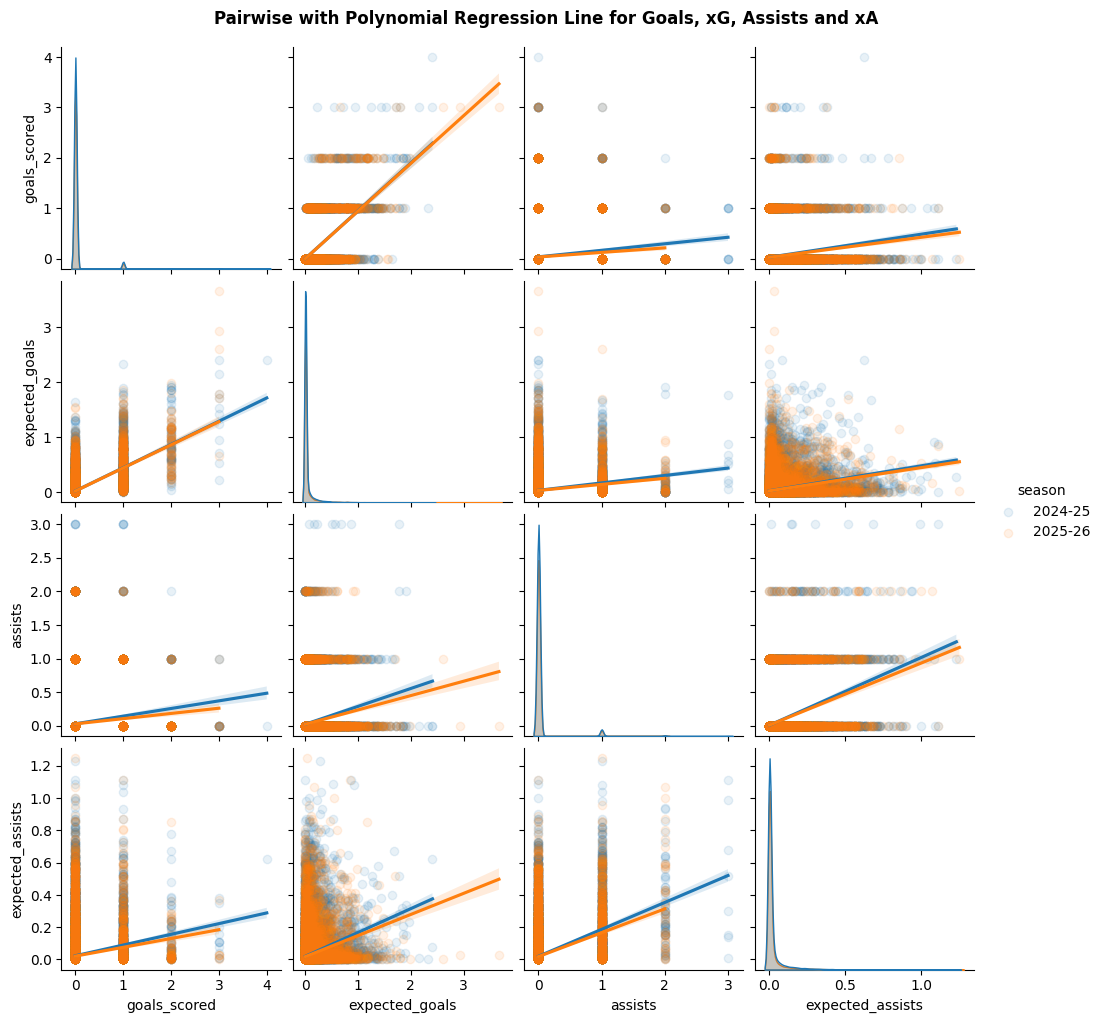

In [ ]:
sns.pairplot(
    data=df_combined[["goals_scored", "expected_goals", "assists", "expected_assists", "season"]],
    hue="season",
    kind="reg",
    diag_kind="kde",
    plot_kws={"scatter_kws": {"alpha": 0.1}},
)

plt.suptitle("Pairwise with Polynomial Regression Line for Goals, xG, Assists and xA",
             y=1.02, fontweight="bold")
plt.show()

### Q4: Plot a regression line and confidence interval
Select two of the features from your dataset and create a lmplot that shows the linear regression between them. Filter your data as you see fit. Include a meaningful title for the plot.

Text(0.5, 0.98, 'Expected Goals vs Total Points')

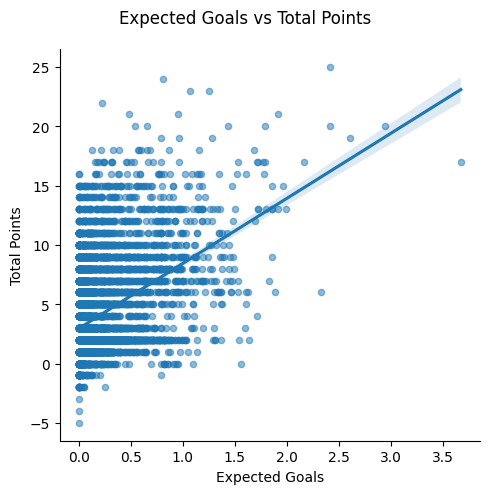

In [ ]:
# Your code here . . .
# Filter to players with 60 min or more playing time
df_lm = df_combined[df_combined["minutes"] >= 60]

g = sns.lmplot(
      data=df_lm,
      x="expected_goals",
      y="total_points",
      height=5,
      ci=95,
      scatter_kws={"s": 20, "alpha": 0.5}
  )

g.set_axis_labels("Expected Goals", "Total Points")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Expected Goals vs Total Points")

### Q5. Create a relplot that shows multiple features in a single plot.
Select two features from your dataset and plot a scatter plot. Select two additional features you want to highlight in your data points using `hue` and `size`. Include a meaningful title to the plot.

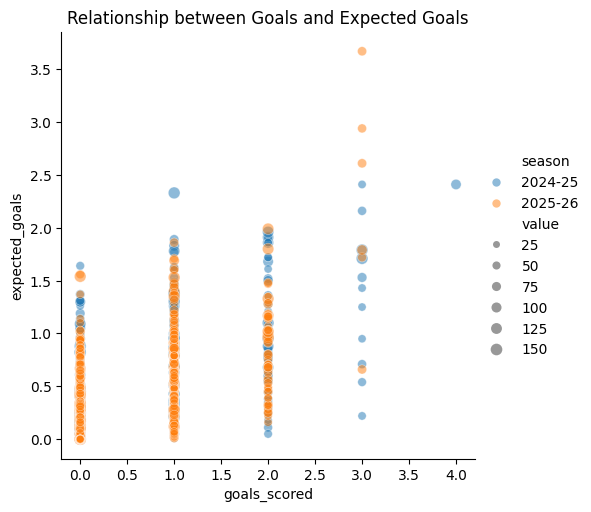

In [ ]:
# Your code here . . .
sns.relplot(
    data=df_combined,
    x="goals_scored",
    y="expected_goals",
    hue="season",
    size="value",
    height=5,
    alpha = 0.5
)

plt.title("Relationship between Goals and Expected Goals")
plt.show()


### Q6: Create a plot with small multiples plots
Select two features from your dataset and show the relationship between the features with an additional feature as the single category. Organize the multiple plots to have 3 plots per row. Set the `height` of the plot to 5 and the size the of data point to 20. Include a meaningful title in the plot.

Text(0.5, 1.02, 'Player Value vs Total Points by Team')

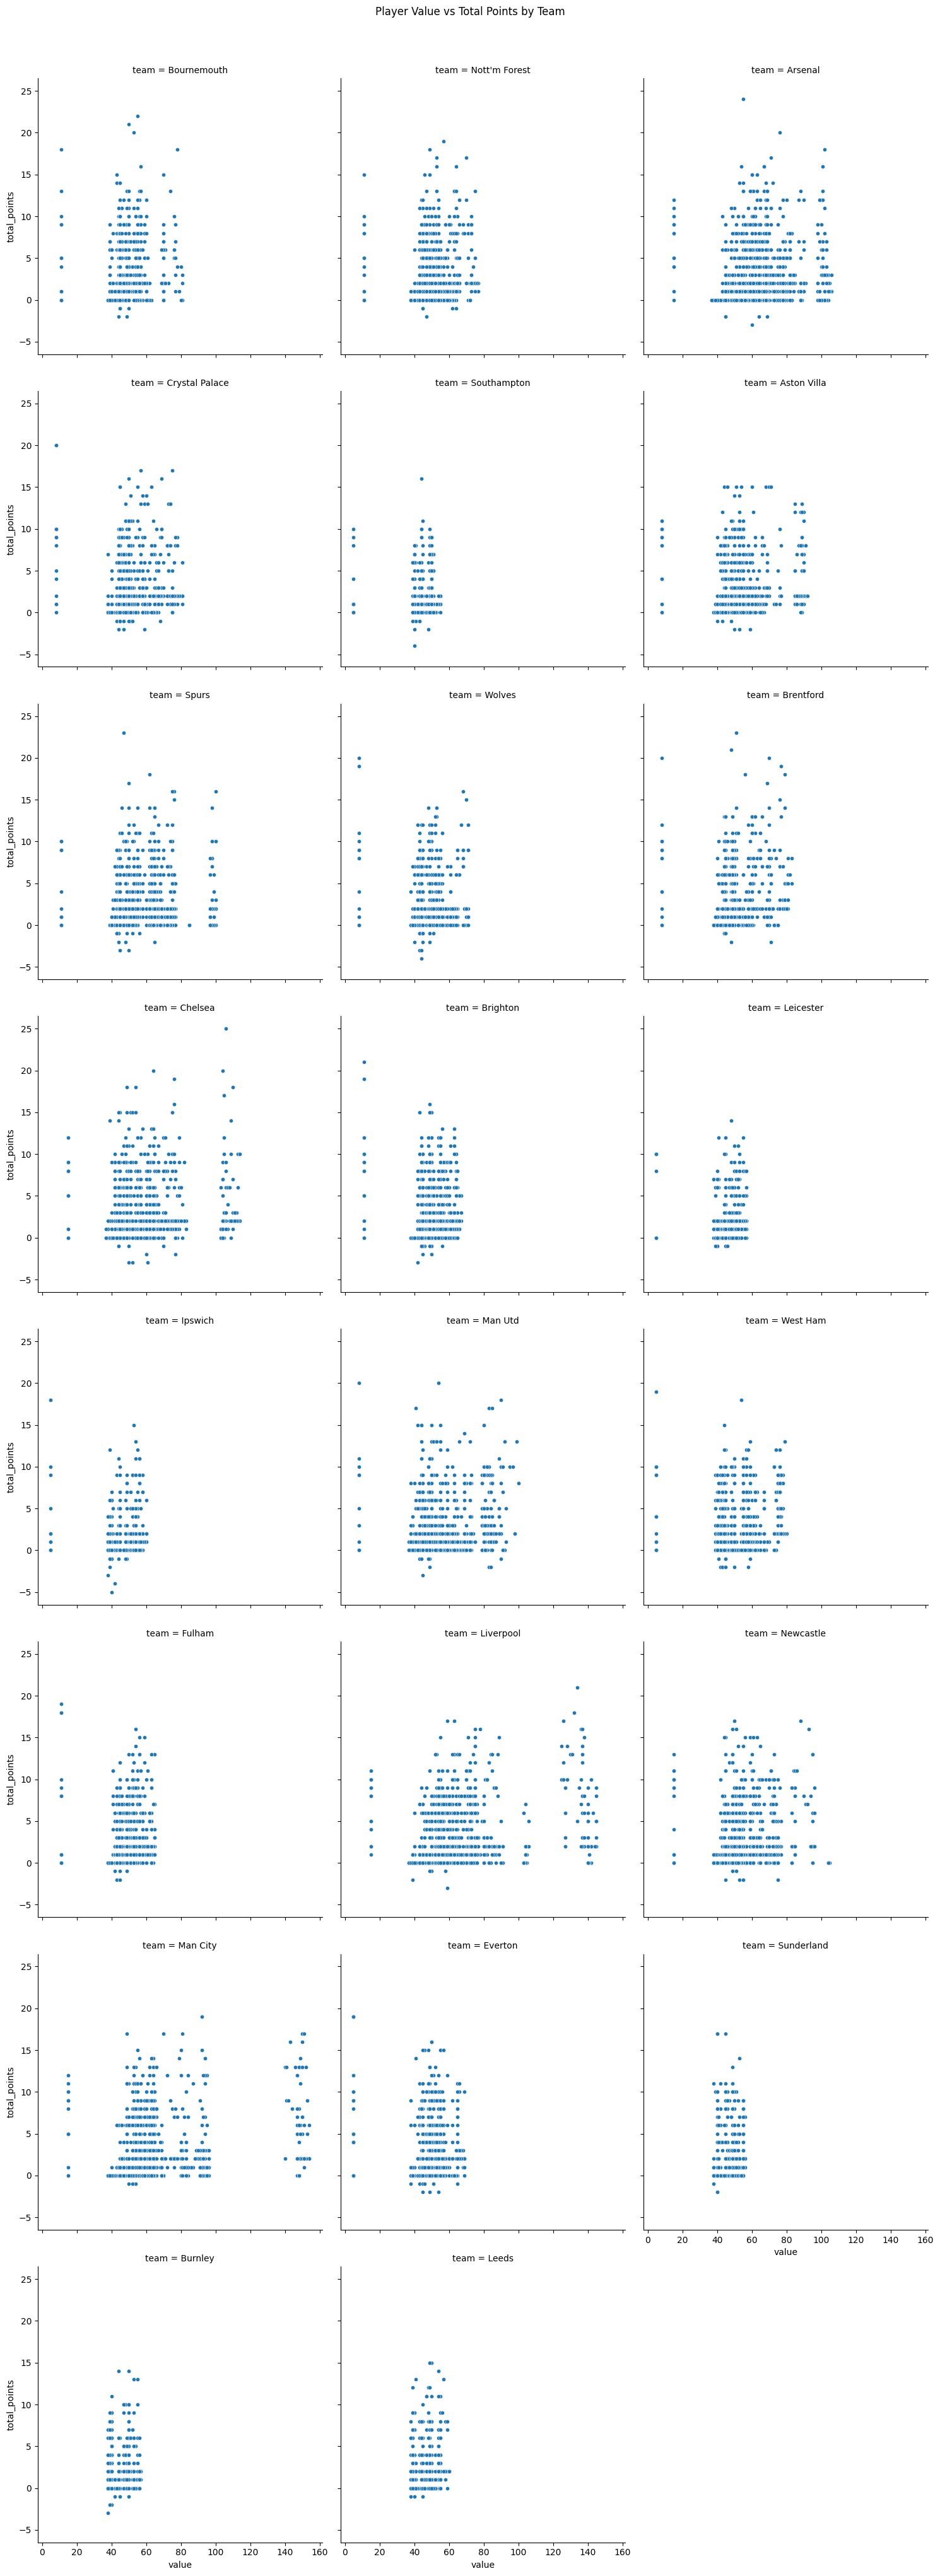

In [ ]:
# Your code here . . .
sns.relplot(data=df_combined, x='value', y='total_points', col='team', col_wrap=3, height=5, s=20)
plt.suptitle('Player Value vs Total Points by Team', y=1.02)